# Right-Censored Four-Method Demo

This notebook cleanly compares four right-censored fits on the same dataset:

1. `CV-IPCW`
2. `EM`
3. `CVEM`
4. `L1MLE`

The focus is on exact score diagnostics and small-MC bias, variance, MSE, and oracle-SD coverage for both density and survival under a truncated normal data-generating process.


## Run Configuration

The next code cell collects the main settings so they are easy to edit.

In particular:

- `REPRESENTATIVE_SEED` controls the single representative run,
- `SMALL_MC_N_SEEDS` and `SMALL_MC_N_WORKERS` control the small Monte Carlo sweep,
- `CVEM` uses `CV_OVERSMOOTH_EM_N_TRIALS` Optuna trials over `CV_OVERSMOOTH_FACTORS` and `CV_OVERSMOOTH_EM_NORM_FACTORS`,
- the bias/variance/MSE summaries and oracle-SD coverage checks are evaluated on `0.05, 0.10, ..., 0.95`,
- the event-time distribution is a truncated normal on `[0, 1]` with independent uniform censoring.


In [1]:
from __future__ import annotations

from contextlib import contextmanager
from pathlib import Path
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from tqdm import tqdm

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists() and (p / "src").exists()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from haldensity.censoring.right import (
    KaplanMeier,
    RightCensoredEMStage,
    RightCensoredObservedL1MLE,
    right_censored_observed_loglik_and_gradient,
)
from haldensity.censoring.right.comparison import (
    evaluate_density_on_grid,
    evaluate_survival_on_grid,
)
from haldensity.censoring.right.metrics import incomplete_loglik
from haldensity.censoring.tuners.right_tuners import (
    RightCensoredCVOversmoothEMTuner,
    RightCensoredInitTuner,
)
from haldensity.utils import TruncatedNormal

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

REPRESENTATIVE_SEED = 3

N = 200
CV_FOLDS = 5
N_TRIALS = 25
CV_OVERSMOOTH_EM_N_TRIALS = 20
N_GRID_POINTS = 200

REFERENCE_TRUNCATED_NORMAL = {
    "mean": 0.5,
    "std": 0.15,
    "lower": 0.0,
    "upper": 1.0,
}

CV_OVERSMOOTH_FACTORS = [0.1, 1.0]
CV_OVERSMOOTH_EM_NORM_FACTORS = [1.0, 2.0]

SMALL_MC_N_SEEDS = 100
SMALL_MC_SEEDS = list(range(1, SMALL_MC_N_SEEDS + 1))
SMALL_MC_N_WORKERS = 2

POINTWISE_MSE_GRID = np.arange(0.05, 1.00, 0.05)

SCORE_N_DIRECTIONS = 40
SCORE_QUADRATURE_N = 2001
SCORE_SEED_MULTIPLIER = 100

SEED_SWEEP = SMALL_MC_SEEDS
N_WORKERS = SMALL_MC_N_WORKERS

STAGE1_OVERRIDES = {
    "basis_order": [0, 1, 2],
    "norm_constraint": {"low": 1.0, "high": 500.0, "log": False},
}
EM_STAGE_KWARGS = {
    "m_imputations": 40,
    "max_em_iter": 10,
    "em_tol": 1e-3,
    "n_grid_points": N_GRID_POINTS,
    "use_sc_adjustment": False,
    "e_step_n_grid": 200,
    "tol": 1e-6,
    "m_step_solver": "CLARABEL",
    "include_intercept_in_constraint": False,
    "verbose": False,
}
OBSERVED_L1_KWARGS = {
    "n_grid_points": N_GRID_POINTS,
    "learning_rate": 0.1,
    "n_iterations": 30000,
    "ll_change_tol": 1e-4,
    "include_intercept_in_constraint": False,
    "history_every": 100,
}

run_config = pd.DataFrame(
    [
        {
            "representative_seed": REPRESENTATIVE_SEED,
            "dgp": "TruncatedNormal(mean=0.5, std=0.15) + Uniform censoring",
            "stage1_n_trials": N_TRIALS,
            "cvem_n_trials": CV_OVERSMOOTH_EM_N_TRIALS,
            "cvem_oversmooth_range": f"{CV_OVERSMOOTH_FACTORS[0]}-{CV_OVERSMOOTH_FACTORS[-1]}",
            "cvem_em_norm_range": f"{CV_OVERSMOOTH_EM_NORM_FACTORS[0]}-{CV_OVERSMOOTH_EM_NORM_FACTORS[-1]}",
            "small_mc_n_seeds": SMALL_MC_N_SEEDS,
            "small_mc_n_workers": SMALL_MC_N_WORKERS,
            "pointwise_mse_grid": "0.05:0.95:0.05",
            "score_n_directions": SCORE_N_DIRECTIONS,
            "score_quadrature_n": SCORE_QUADRATURE_N,
        }
    ]
)
display(run_config)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,representative_seed,dgp,stage1_n_trials,cvem_n_trials,cvem_oversmooth_range,cvem_em_norm_range,small_mc_n_seeds,small_mc_n_workers,pointwise_mse_grid,score_n_directions,score_quadrature_n
0,3,"TruncatedNormal(mean=0.5, std=0.15) + Uniform ...",25,20,0.1-1.0,1.0-2.0,100,2,0.05:0.95:0.05,40,2001


In [8]:
# Fitting and diagnostic helpers.

def simulate_reference_right_censored_dgp(n: int, *, seed: int) -> dict:
    np.random.seed(seed)
    sampler = TruncatedNormal(**REFERENCE_TRUNCATED_NORMAL)
    t_event = sampler.generate_samples(n)
    t_cens = np.random.uniform(0.0, 1.0, size=n)
    observed_time = np.minimum(t_event, t_cens)
    delta = (t_event <= t_cens).astype(int)

    return {
        "observed_data": pd.DataFrame({"T": observed_time, "Delta": delta}),
        "truth": {
            "density_fn": lambda t, _sampler=sampler: _sampler.compute_density(np.asarray(t, dtype=float)),
            "survival_fn": lambda t, _sampler=sampler: 1.0 - _sampler.compute_cdf(np.asarray(t, dtype=float)),
        },
    }


def fit_stage1_cv_ipcw(data: pd.DataFrame, *, seed: int) -> dict:
    tic = time.perf_counter()
    tuner = RightCensoredInitTuner(
        data=data,
        cv_folds=CV_FOLDS,
        random_state=seed,
        n_grid_points=N_GRID_POINTS,
        param_overrides=STAGE1_OVERRIDES,
        use_conservative_adjustment=False,
        silent=True,
        validation_metric="ipcw_loglik",
    )
    result = tuner.optimize(n_trials=N_TRIALS)
    runtime_seconds = time.perf_counter() - tic
    return {
        "tuning_result": result,
        "estimator": result.estimator,
        "runtime_seconds": float(runtime_seconds),
    }


def compress_theta_to_selected_support(estimator) -> np.ndarray:
    support = np.asarray(estimator.grid_points_hal_selected, dtype=float)
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float)
    theta_full = np.asarray(estimator.theta_hat, dtype=float)
    basis_order = int(estimator.basis_order)
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + support.size, dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(support):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise RuntimeError("selected support knot was not found in the full Stage 1 grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]
    return theta_selected


def run_em(data: pd.DataFrame, stage1_estimator, *, seed: int) -> dict:
    km = KaplanMeier().fit(data, time_col="T", delta_col="Delta")
    stage = RightCensoredEMStage(
        norm_constraint=float(stage1_estimator.norm_constraint),
        rng_seed=seed,
        **EM_STAGE_KWARGS,
    )

    tic = time.perf_counter()
    result = stage.run(
        initial_estimator=stage1_estimator,
        data=data,
        S_c_predict=lambda t: np.atleast_1d(km.predict(t)),
    )
    runtime_seconds = time.perf_counter() - tic

    estimator = result.final_estimator
    return {
        "estimator": estimator,
        "results": estimator.get_results(),
        "runtime_seconds": float(runtime_seconds),
        "em_iterations": int(result.em_iterations),
        "em_converged": bool(result.em_converged),
        "observed_loglik": float(incomplete_loglik(estimator, data)),
    }


def fit_cvem(data: pd.DataFrame, stage1_estimator, *, seed: int) -> dict:
    tic = time.perf_counter()
    tuning_result = RightCensoredCVOversmoothEMTuner(
        data=data,
        stage1_estimator=stage1_estimator,
        cv_folds=CV_FOLDS,
        oversmooth_factors=CV_OVERSMOOTH_FACTORS,
        em_norm_factors=CV_OVERSMOOTH_EM_NORM_FACTORS,
        em_m_imputations=EM_STAGE_KWARGS["m_imputations"],
        em_max_em_iter=EM_STAGE_KWARGS["max_em_iter"],
        em_tol=EM_STAGE_KWARGS["em_tol"],
        em_e_step_n_grid=EM_STAGE_KWARGS["e_step_n_grid"],
        em_use_sc_adjustment=EM_STAGE_KWARGS["use_sc_adjustment"],
        n_grid_points=N_GRID_POINTS,
        random_state=seed,
        solver=EM_STAGE_KWARGS["m_step_solver"],
        silent=True,
    ).optimize(n_trials=CV_OVERSMOOTH_EM_N_TRIALS)
    runtime_seconds = time.perf_counter() - tic

    estimator = tuning_result.estimator
    best_record = tuning_result.metadata["best_record"]
    return {
        "estimator": estimator,
        "tuning_result": tuning_result,
        "runtime_seconds": float(runtime_seconds),
        "observed_loglik": float(incomplete_loglik(estimator, data)),
        "best_oversmooth_factor": float(tuning_result.best_params["oversmooth_factor"]),
        "best_em_norm_factor": float(tuning_result.best_params["em_norm_factor"]),
        "best_cv_loglik": float(best_record.mean_cv_ll),
        "best_cv_sd": float(best_record.sd_cv_ll),
    }


def fit_l1mle(data: pd.DataFrame, stage1_estimator) -> dict:
    warm_start = compress_theta_to_selected_support(stage1_estimator)
    tic = time.perf_counter()
    estimator = RightCensoredObservedL1MLE(
        working_grid_points=np.asarray(stage1_estimator.grid_points_hal_selected, dtype=float),
        norm_constraint=float(stage1_estimator.norm_constraint),
        basis_order=int(stage1_estimator.basis_order),
        warm_start_theta=warm_start,
        **OBSERVED_L1_KWARGS,
    ).fit(data)
    runtime_seconds = time.perf_counter() - tic

    results = estimator.get_results()
    return {
        "estimator": estimator,
        "results": results,
        "runtime_seconds": float(runtime_seconds),
        "n_iterations_run": int(results["n_iterations_run"]),
        "converged": bool(results["converged"]),
        "observed_loglik": float(incomplete_loglik(estimator, data)),
    }


# Shared-support score helpers.

def compress_to_selected_support(estimator, *, coef_tol: float = 1e-8) -> dict:
    basis_order = int(estimator.basis_order)
    theta_full = np.asarray(estimator.theta_hat, dtype=float).copy()
    selected_knots = np.asarray(estimator.grid_points_hal_selected, dtype=float).copy()
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float).copy()
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + len(selected_knots), dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(selected_knots):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise ValueError(f"Unable to match selected knot {knot} in full working grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]

    return {
        "theta_hat": theta_selected,
        "working_grid_points": selected_knots,
        "basis_order": basis_order,
        "include_intercept_in_constraint": bool(getattr(estimator, "include_intercept_in_constraint", False)),
        "norm_constraint": float(getattr(estimator, "norm_constraint", np.nan)),
        "coef_tol": float(getattr(estimator, "tol", coef_tol)),
    }


def sample_l1_constant_direction(theta, *, include_intercept_in_constraint=False, coef_tol=1e-8, rng, max_tries=64):
    start_idx = 0 if include_intercept_in_constraint else 1
    active = np.where(np.abs(theta[start_idx:]) > float(coef_tol))[0] + start_idx
    if active.size < 2:
        return None, active

    weights = np.abs(theta[active])
    denom = float(np.dot(weights, weights))
    if not np.isfinite(denom) or denom <= 0.0:
        return None, active

    for _ in range(int(max_tries)):
        h = rng.normal(size=active.size)
        h -= float(np.dot(h, weights)) / denom * weights
        max_abs = float(np.max(np.abs(h)))
        if np.isfinite(max_abs) and max_abs > 1e-10:
            return h / max_abs, active
    return None, active


def exact_constraint_score(theta, grad, h, active_idx):
    velocity = theta[active_idx] * h
    return float(np.dot(grad[active_idx], velocity))


def score_rng_seed(seed: int, offset: int) -> int:
    return int(seed * SCORE_SEED_MULTIPLIER + offset)


def score_diagnostics(
    estimator,
    observed_df: pd.DataFrame,
    *,
    rng_seed: int,
    n_directions: int = SCORE_N_DIRECTIONS,
    quadrature_n: int = SCORE_QUADRATURE_N,
) -> dict:
    state = compress_to_selected_support(estimator)
    theta = np.asarray(state["theta_hat"], dtype=float)
    ll, grad = right_censored_observed_loglik_and_gradient(
        theta,
        observed_df,
        working_grid_points=state["working_grid_points"],
        basis_order=state["basis_order"],
        n_grid_points=quadrature_n,
        min_tail_mass=1e-12,
    )

    n_obs = float(observed_df.shape[0])
    ll = float(ll) / n_obs
    grad = np.asarray(grad, dtype=float) / n_obs

    start_idx = 0 if state["include_intercept_in_constraint"] else 1
    penalized_grad = grad[start_idx:]

    rng = np.random.default_rng(int(rng_seed))
    abs_constraint_scores = []
    for _ in range(int(n_directions)):
        h, active_idx = sample_l1_constant_direction(
            theta,
            include_intercept_in_constraint=state["include_intercept_in_constraint"],
            coef_tol=state["coef_tol"],
            rng=rng,
        )
        if h is None:
            break
        abs_constraint_scores.append(abs(exact_constraint_score(theta, grad, h, active_idx)))

    return {
        "observed_loglik": ll,
        "max_abs_observed_score": float(np.max(np.abs(penalized_grad))) if penalized_grad.size else 0.0,
        "l2_observed_score": float(np.linalg.norm(penalized_grad)),
        "n_constraint_directions": int(len(abs_constraint_scores)),
        "median_abs_constraint_score": float(np.median(abs_constraint_scores)) if abs_constraint_scores else float("nan"),
        "max_abs_constraint_score": float(np.max(abs_constraint_scores)) if abs_constraint_scores else float("nan"),
    }


# Truth-on-grid error helpers.

def pointwise_mse_on_grid(estimator, truth: dict, *, grid: np.ndarray = POINTWISE_MSE_GRID) -> dict:
    eval_grid = np.asarray(grid, dtype=float)
    est_density = evaluate_density_on_grid(estimator, eval_grid)
    est_survival = evaluate_survival_on_grid(estimator, eval_grid)
    truth_density = np.asarray(truth["density_fn"](eval_grid), dtype=float)
    truth_survival = np.asarray(truth["survival_fn"](eval_grid), dtype=float)

    return {
        "density_pointwise_mse": float(np.mean(np.square(est_density - truth_density))),
        "survival_pointwise_mse": float(np.mean(np.square(est_survival - truth_survival))),
    }


def build_method_summary_row(
    *,
    seed: int,
    method: str,
    family: str,
    estimator,
    score: dict,
    mse: dict,
    runtime_seconds: float = np.nan,
    em_iterations: float = np.nan,
    optimizer_iterations: float = np.nan,
    cv_oversmooth_factor: float = np.nan,
    cv_em_norm_factor: float = np.nan,
) -> dict:
    return {
        "seed": int(seed),
        "method": method,
        "family": family,
        "runtime_seconds": float(runtime_seconds),
        "observed_loglik": float(score["observed_loglik"]),
        "max_abs_observed_score": float(score["max_abs_observed_score"]),
        "median_abs_constraint_score": float(score["median_abs_constraint_score"]),
        "density_pointwise_mse": float(mse["density_pointwise_mse"]),
        "survival_pointwise_mse": float(mse["survival_pointwise_mse"]),
        "support_size": int(len(estimator.grid_points_hal_selected)),
        "em_iterations": float(em_iterations),
        "optimizer_iterations": float(optimizer_iterations),
        "cv_oversmooth_factor": float(cv_oversmooth_factor),
        "cv_em_norm_factor": float(cv_em_norm_factor),
    }


def build_pointwise_rows(
    *,
    seed: int,
    method: str,
    estimator,
    truth: dict,
    grid: np.ndarray = POINTWISE_MSE_GRID,
) -> list[dict]:
    eval_grid = np.asarray(grid, dtype=float)
    density_est = np.asarray(evaluate_density_on_grid(estimator, eval_grid), dtype=float)
    survival_est = np.asarray(evaluate_survival_on_grid(estimator, eval_grid), dtype=float)
    truth_density = np.asarray(truth["density_fn"](eval_grid), dtype=float)
    truth_survival = np.asarray(truth["survival_fn"](eval_grid), dtype=float)

    rows = []
    for estimand, estimates, truths in [
        ("density", density_est, truth_density),
        ("survival", survival_est, truth_survival),
    ]:
        for eval_point, estimate, truth_value in zip(eval_grid, estimates, truths):
            error = float(estimate - truth_value)
            rows.append(
                {
                    "seed": int(seed),
                    "method": method,
                    "estimand": estimand,
                    "eval_point": float(eval_point),
                    "estimate": float(estimate),
                    "truth": float(truth_value),
                    "error": error,
                    "squared_error": float(error ** 2),
                }
            )
    return rows


# Parallel small-MC helpers.

@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()


def run_small_mc_seed(seed: int) -> dict:
    simulation_seed = simulate_reference_right_censored_dgp(n=N, seed=seed)
    data_seed = simulation_seed["observed_data"]
    truth_seed = simulation_seed["truth"]
    stage1_fit_seed = fit_stage1_cv_ipcw(data_seed, seed=seed)
    stage1_seed = stage1_fit_seed["estimator"]

    em_seed = run_em(data_seed, stage1_seed, seed=seed)
    cvem_seed = fit_cvem(data_seed, stage1_seed, seed=seed)
    l1_seed = fit_l1mle(data_seed, stage1_seed)

    stage1_score_seed = score_diagnostics(stage1_seed, data_seed, rng_seed=score_rng_seed(seed, 1))
    em_score_seed = score_diagnostics(em_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 2))
    cvem_score_seed = score_diagnostics(cvem_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 3))
    l1_score_seed = score_diagnostics(l1_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 4))

    stage1_mse_seed = pointwise_mse_on_grid(stage1_seed, truth_seed)
    em_mse_seed = pointwise_mse_on_grid(em_seed["estimator"], truth_seed)
    cvem_mse_seed = pointwise_mse_on_grid(cvem_seed["estimator"], truth_seed)
    l1_mse_seed = pointwise_mse_on_grid(l1_seed["estimator"], truth_seed)

    method_rows = [
        build_method_summary_row(
            seed=seed,
            method="CV-IPCW",
            family="Stage 1",
            estimator=stage1_seed,
            score=stage1_score_seed,
            mse=stage1_mse_seed,
        ),
        build_method_summary_row(
            seed=seed,
            method="EM",
            family="EM",
            estimator=em_seed["estimator"],
            score=em_score_seed,
            mse=em_mse_seed,
            runtime_seconds=em_seed["runtime_seconds"],
            em_iterations=em_seed["em_iterations"],
        ),
        build_method_summary_row(
            seed=seed,
            method="CVEM",
            family="CVEM",
            estimator=cvem_seed["estimator"],
            score=cvem_score_seed,
            mse=cvem_mse_seed,
            runtime_seconds=cvem_seed["runtime_seconds"],
            cv_oversmooth_factor=cvem_seed["best_oversmooth_factor"],
            cv_em_norm_factor=cvem_seed["best_em_norm_factor"],
        ),
        build_method_summary_row(
            seed=seed,
            method="L1MLE",
            family="L1MLE",
            estimator=l1_seed["estimator"],
            score=l1_score_seed,
            mse=l1_mse_seed,
            runtime_seconds=l1_seed["runtime_seconds"],
            optimizer_iterations=l1_seed["n_iterations_run"],
        ),
    ]

    pointwise_rows = []
    for method_name, estimator in [
        ("CV-IPCW", stage1_seed),
        ("EM", em_seed["estimator"]),
        ("CVEM", cvem_seed["estimator"]),
        ("L1MLE", l1_seed["estimator"]),
    ]:
        pointwise_rows.extend(
            build_pointwise_rows(
                seed=seed,
                method=method_name,
                estimator=estimator,
                truth=truth_seed,
            )
        )

    return {
        "method_rows": method_rows,
        "pointwise_rows": pointwise_rows,
    }


In [9]:
# Representative single-seed run.

simulation = simulate_reference_right_censored_dgp(n=N, seed=REPRESENTATIVE_SEED)
observed_data = simulation["observed_data"]
truth = simulation["truth"]

stage1_fit = fit_stage1_cv_ipcw(observed_data, seed=REPRESENTATIVE_SEED)
stage1_estimator = stage1_fit["estimator"]

em_run = run_em(observed_data, stage1_estimator, seed=REPRESENTATIVE_SEED)
cvem_run = fit_cvem(observed_data, stage1_estimator, seed=REPRESENTATIVE_SEED)
l1_run = fit_l1mle(observed_data, stage1_estimator)

stage1_score = score_diagnostics(stage1_estimator, observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 1))
em_score = score_diagnostics(em_run["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 2))
cvem_score = score_diagnostics(cvem_run["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 3))
l1_score = score_diagnostics(l1_run["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 4))

stage1_mse = pointwise_mse_on_grid(stage1_estimator, truth)
em_mse = pointwise_mse_on_grid(em_run["estimator"], truth)
cvem_mse = pointwise_mse_on_grid(cvem_run["estimator"], truth)
l1_mse = pointwise_mse_on_grid(l1_run["estimator"], truth)

plot_method_order = ["CV-IPCW", "EM", "CVEM", "L1MLE"]

representative_meta = pd.DataFrame(
    [
        {
            "seed": REPRESENTATIVE_SEED,
            "n_observed": int(observed_data.shape[0]),
            "n_events": int(observed_data["Delta"].sum()),
            "n_censored": int((1 - observed_data["Delta"]).sum()),
            "stage1_basis_order": int(stage1_fit["tuning_result"].best_params["basis_order"]),
            "stage1_norm_constraint": float(stage1_fit["tuning_result"].best_params["norm_constraint"]),
            "stage1_support_size": int(len(stage1_estimator.grid_points_hal_selected)),
            "dgp_mean": float(REFERENCE_TRUNCATED_NORMAL["mean"]),
            "dgp_std": float(REFERENCE_TRUNCATED_NORMAL["std"]),
        }
    ]
)

representative_rows = [
    build_method_summary_row(
        seed=REPRESENTATIVE_SEED,
        method="CV-IPCW",
        family="Stage 1",
        estimator=stage1_estimator,
        score=stage1_score,
        mse=stage1_mse,
    ),
    build_method_summary_row(
        seed=REPRESENTATIVE_SEED,
        method="EM",
        family="EM",
        estimator=em_run["estimator"],
        score=em_score,
        mse=em_mse,
        runtime_seconds=em_run["runtime_seconds"],
        em_iterations=em_run["em_iterations"],
    ),
    build_method_summary_row(
        seed=REPRESENTATIVE_SEED,
        method="CVEM",
        family="CVEM",
        estimator=cvem_run["estimator"],
        score=cvem_score,
        mse=cvem_mse,
        runtime_seconds=cvem_run["runtime_seconds"],
        cv_oversmooth_factor=cvem_run["best_oversmooth_factor"],
        cv_em_norm_factor=cvem_run["best_em_norm_factor"],
    ),
    build_method_summary_row(
        seed=REPRESENTATIVE_SEED,
        method="L1MLE",
        family="L1MLE",
        estimator=l1_run["estimator"],
        score=l1_score,
        mse=l1_mse,
        runtime_seconds=l1_run["runtime_seconds"],
        optimizer_iterations=l1_run["n_iterations_run"],
    ),
]
representative_df = pd.DataFrame(representative_rows)
representative_df["method"] = pd.Categorical(
    representative_df["method"], categories=plot_method_order, ordered=True
)
representative_df = representative_df.sort_values("method").reset_index(drop=True)

representative_display = representative_df[
    [
        "method",
        "observed_loglik",
        "max_abs_observed_score",
        "median_abs_constraint_score",
        "density_pointwise_mse",
        "survival_pointwise_mse",
        "runtime_seconds",
        "em_iterations",
        "optimizer_iterations",
        "support_size",
        "cv_oversmooth_factor",
        "cv_em_norm_factor",
    ]
]

cvem_tuning_summary = pd.DataFrame(
    [
        {
            "best_oversmooth_factor": float(cvem_run["best_oversmooth_factor"]),
            "best_em_norm_factor": float(cvem_run["best_em_norm_factor"]),
            "best_cv_loglik": float(cvem_run["best_cv_loglik"]),
            "best_cv_sd": float(cvem_run["best_cv_sd"]),
        }
    ]
)

display(observed_data.head())
display(representative_meta)
display(representative_display)
display(cvem_tuning_summary)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,T,Delta
0,0.068550,0
1,0.076496,0
2,0.417467,1
3,0.075566,0
4,0.183772,0


,seed,n_observed,n_events,n_censored,stage1_basis_order,stage1_norm_constraint,stage1_support_size,dgp_mean,dgp_std
0,3,200,96,104,2,145.077701,20,0.5,0.15


,method,observed_loglik,max_abs_observed_score,median_abs_constraint_score,density_pointwise_mse,survival_pointwise_mse,runtime_seconds,em_iterations,optimizer_iterations,support_size,cv_oversmooth_factor,cv_em_norm_factor
0,CV-IPCW,0.133286,0.000286,0.002991,0.015690,0.000368,NaN,NaN,NaN,20,NaN,NaN
1,EM,0.134971,0.000175,0.001863,0.021532,0.000416,0.137766,9.0,NaN,20,NaN,NaN
2,CVEM,0.134594,0.000311,0.034733,0.013634,0.000340,13.853729,NaN,NaN,2,0.117555,1.767069
3,L1MLE,0.133287,0.000202,0.001625,0.015466,0.000361,0.000956,NaN,2.0,20,NaN,NaN


,best_oversmooth_factor,best_em_norm_factor,best_cv_loglik,best_cv_sd
0,0.117555,1.767069,4.806211,4.645986


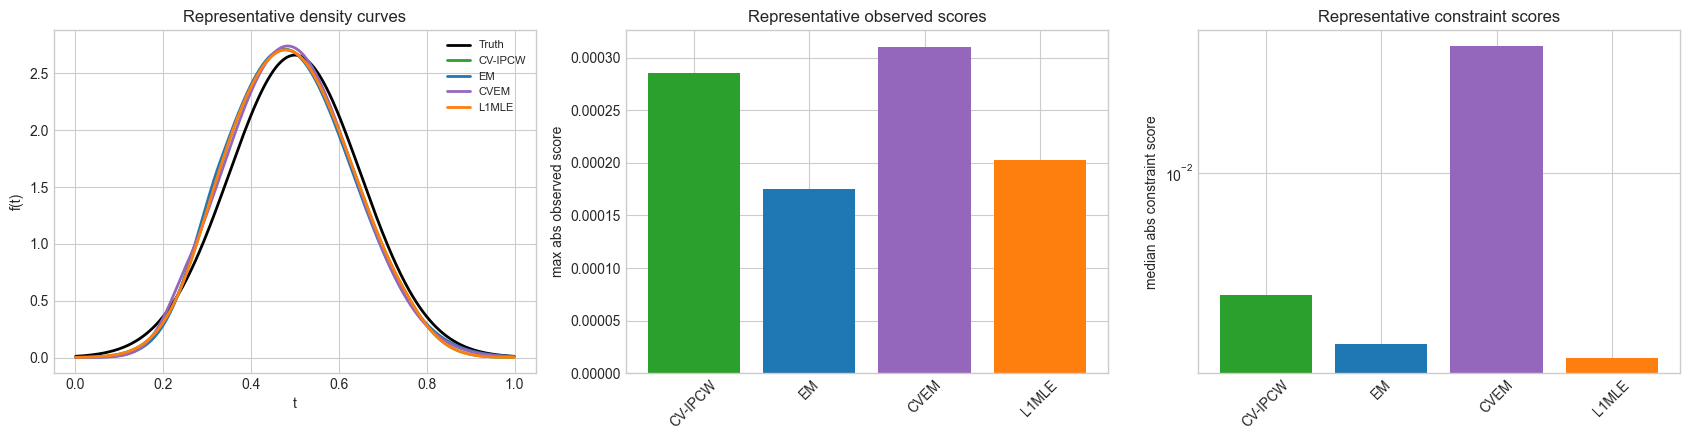

,t,truth,cv_ipcw,em,cvem,l1mle
0,0.25,0.952598,0.961746,0.964957,0.959545,0.961822
1,0.50,0.500000,0.461804,0.458084,0.464167,0.462192
2,0.75,0.047402,0.034194,0.038787,0.036517,0.034263


In [4]:
# Representative plots.

plot_grid = np.linspace(0.001, 0.999, 400)
method_color_map = {
    "CV-IPCW": "tab:green",
    "EM": "tab:blue",
    "CVEM": "tab:purple",
    "L1MLE": "tab:orange",
}
method_estimator_map = {
    "CV-IPCW": stage1_estimator,
    "EM": em_run["estimator"],
    "CVEM": cvem_run["estimator"],
    "L1MLE": l1_run["estimator"],
}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(plot_grid, truth["density_fn"](plot_grid), color="black", linewidth=2, label="Truth")
for method in plot_method_order:
    axes[0].plot(
        plot_grid,
        method_estimator_map[method].get_density_at_points(plot_grid),
        color=method_color_map[method],
        linewidth=2,
        label=method,
    )
axes[0].set_title("Representative density curves")
axes[0].set_xlabel("t")
axes[0].set_ylabel("f(t)")
axes[0].legend(fontsize=8)

rep_plot_df = representative_df.copy()
bar_colors = [method_color_map[method] for method in rep_plot_df["method"].astype(str)]
axes[1].bar(rep_plot_df["method"].astype(str), rep_plot_df["max_abs_observed_score"], color=bar_colors)
axes[1].set_title("Representative observed scores")
axes[1].set_ylabel("max abs observed score")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(
    rep_plot_df["method"].astype(str),
    np.maximum(rep_plot_df["median_abs_constraint_score"], 1e-12),
    color=bar_colors,
)
axes[2].set_title("Representative constraint scores")
axes[2].set_ylabel("median abs constraint score")
axes[2].set_yscale("log")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

survival_snapshot = pd.DataFrame(
    {
        "t": [0.25, 0.5, 0.75],
        "truth": truth["survival_fn"](np.array([0.25, 0.5, 0.75])),
        "cv_ipcw": evaluate_survival_on_grid(stage1_estimator, np.array([0.25, 0.5, 0.75])),
        "em": evaluate_survival_on_grid(em_run["estimator"], np.array([0.25, 0.5, 0.75])),
        "cvem": evaluate_survival_on_grid(cvem_run["estimator"], np.array([0.25, 0.5, 0.75])),
        "l1mle": evaluate_survival_on_grid(l1_run["estimator"], np.array([0.25, 0.5, 0.75])),
    }
)
display(survival_snapshot)


In [5]:
# Small-MC sweep in parallel.

with tqdm_joblib(tqdm(total=len(SEED_SWEEP), desc=f"Small MC sweep ({N_WORKERS} workers)")):
    seed_results = Parallel(n_jobs=N_WORKERS, backend="loky")(
        delayed(run_small_mc_seed)(seed) for seed in SEED_SWEEP
    )

method_rows = [row for result in seed_results for row in result["method_rows"]]
pointwise_rows = [row for result in seed_results for row in result["pointwise_rows"]]

method_summary = pd.DataFrame(method_rows)
method_summary["method"] = pd.Categorical(
    method_summary["method"], categories=plot_method_order, ordered=True
)
method_summary = method_summary.sort_values(["seed", "method"]).reset_index(drop=True)

method_median_summary = (
    method_summary.groupby("method", as_index=False, observed=False)
    .agg(
        n_seeds=("seed", "size"),
        median_runtime_seconds=("runtime_seconds", "median"),
        median_observed_loglik=("observed_loglik", "median"),
        median_max_abs_observed_score=("max_abs_observed_score", "median"),
        median_median_abs_constraint_score=("median_abs_constraint_score", "median"),
        median_density_pointwise_mse=("density_pointwise_mse", "median"),
        median_survival_pointwise_mse=("survival_pointwise_mse", "median"),
    )
)
method_median_summary["median_runtime_ms"] = 1000.0 * method_median_summary["median_runtime_seconds"]

pointwise_summary = pd.DataFrame(pointwise_rows).sort_values(
    ["estimand", "method", "eval_point", "seed"]
).reset_index(drop=True)

pointwise_metric_rows = []
for (method, estimand, eval_point), group in pointwise_summary.groupby(
    ["method", "estimand", "eval_point"],
    sort=True,
):
    estimates = group["estimate"].to_numpy(dtype=float)
    truth_value = float(group["truth"].iloc[0])
    mean_estimate = float(np.mean(estimates))
    bias = float(mean_estimate - truth_value)
    variance = float(np.mean((estimates - mean_estimate) ** 2))
    mse = float(np.mean(np.square(estimates - truth_value)))
    pointwise_metric_rows.append(
        {
            "method": method,
            "estimand": estimand,
            "eval_point": float(eval_point),
            "truth": truth_value,
            "mean_estimate": mean_estimate,
            "bias": bias,
            "variance": variance,
            "mse": mse,
        }
    )

pointwise_metric_summary = pd.DataFrame(pointwise_metric_rows)
pointwise_metric_summary["method"] = pd.Categorical(
    pointwise_metric_summary["method"], categories=plot_method_order, ordered=True
)
pointwise_metric_summary = pointwise_metric_summary.sort_values(
    ["estimand", "method", "eval_point"]
).reset_index(drop=True)

pointwise_metric_overview = (
    pointwise_metric_summary.groupby(["method", "estimand"], as_index=False, observed=False)
    .agg(
        mean_abs_bias=("bias", lambda s: float(np.mean(np.abs(np.asarray(s, dtype=float))))),
        mean_variance=("variance", "mean"),
        mean_mse=("mse", "mean"),
    )
)

display(method_median_summary)
display(pointwise_metric_overview)


Small MC sweep (2 workers):   0%|          | 0/100 [00:00<?, ?it/s]/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
Small MC sweep (2 workers):  15%|█▌        | 15/100 [04:12<21:52, 15.44s/it] /Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
Small MC sweep (2 workers): 100%|██████████| 100/100 [23:58<00:00, 14.38s/it]


,method,n_seeds,median_runtime_seconds,median_observed_loglik,median_max_abs_observed_score,median_median_abs_constraint_score,median_density_pointwise_mse,median_survival_pointwise_mse,median_runtime_ms
0,CV-IPCW,100,NaN,0.113981,0.001015,0.003139,0.049520,0.000544,NaN
1,EM,100,0.169186,0.115148,0.000650,0.003586,0.045940,0.000479,169.185812
2,CVEM,100,20.781568,0.116855,0.000482,0.005837,0.045287,0.000496,20781.568355
3,L1MLE,100,0.005622,0.115133,0.000220,0.000727,0.049788,0.000524,5.622104


,method,estimand,mean_abs_bias,mean_variance,mean_mse
0,CV-IPCW,density,0.082989,0.132835,0.143544
1,CV-IPCW,survival,0.014633,0.002665,0.002980
2,EM,density,0.100020,0.131238,0.144239
3,EM,survival,0.016173,0.002545,0.002860
4,CVEM,density,0.081563,0.123460,0.131656
5,CVEM,survival,0.012945,0.002168,0.002370
6,L1MLE,density,0.100470,0.132260,0.145907
7,L1MLE,survival,0.016281,0.002550,0.002869


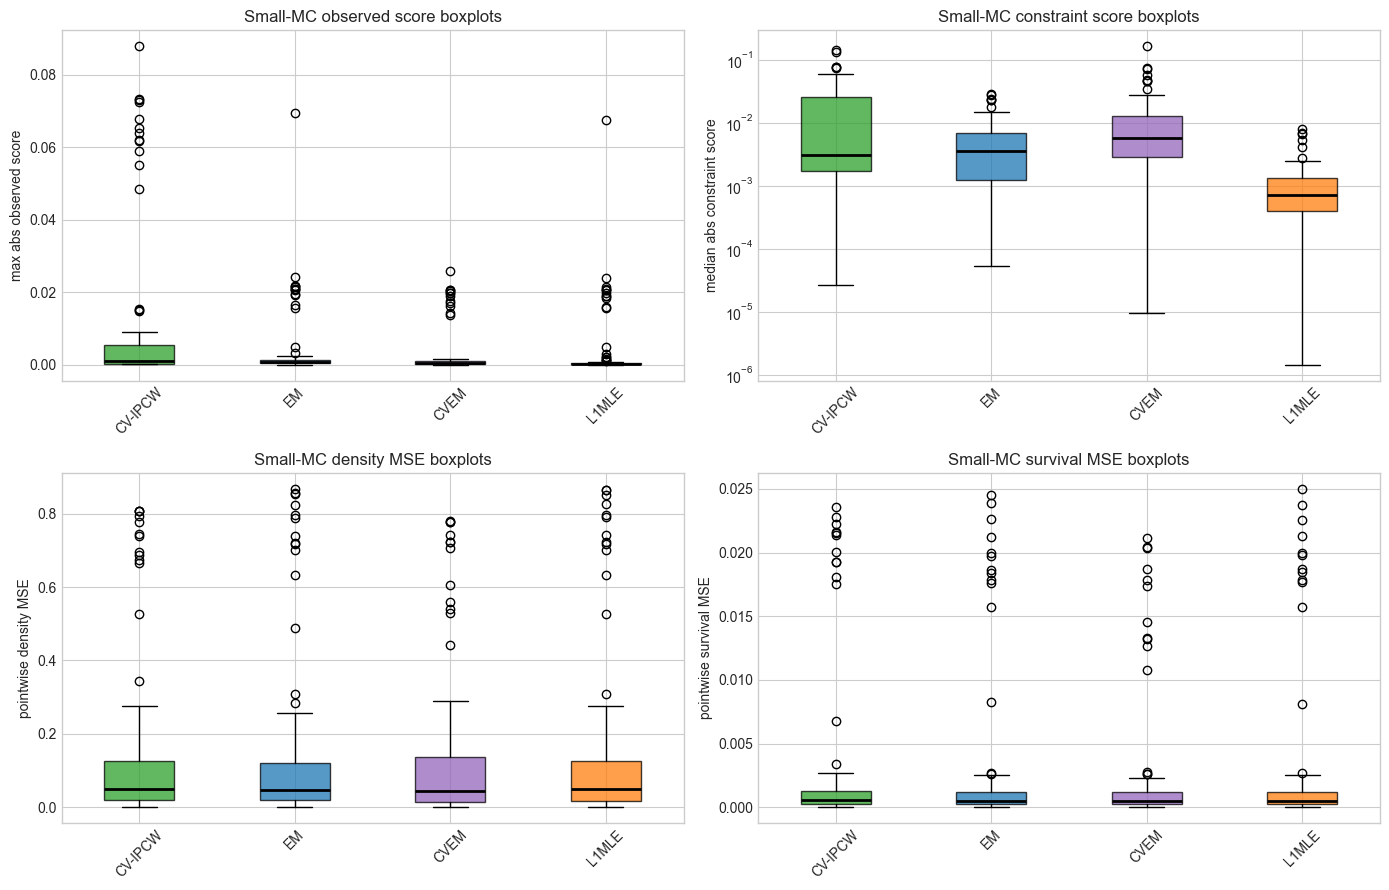

In [10]:
# Small-MC score and MSE boxplots.

boxplot_methods = plot_method_order
boxplot_colors = method_color_map
plot_method_summary = method_summary.copy()


def boxplot_values(column: str, *, lower_clip: float | None = None) -> list[np.ndarray]:
    values_by_method = []
    for method in boxplot_methods:
        values = plot_method_summary.loc[
            plot_method_summary["method"] == method, column
        ].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        if lower_clip is not None:
            values = np.fmax(values, lower_clip)
        values_by_method.append(values if values.size else np.array([np.nan]))
    return values_by_method


observed_box_data = boxplot_values("max_abs_observed_score")
constraint_box_data = boxplot_values("median_abs_constraint_score", lower_clip=1e-12)
density_mse_box_data = boxplot_values("density_pointwise_mse")
survival_mse_box_data = boxplot_values("survival_pointwise_mse")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
observed_box = axes[0, 0].boxplot(observed_box_data, tick_labels=boxplot_methods, patch_artist=True)
constraint_box = axes[0, 1].boxplot(constraint_box_data, tick_labels=boxplot_methods, patch_artist=True)
density_mse_box = axes[1, 0].boxplot(density_mse_box_data, tick_labels=boxplot_methods, patch_artist=True)
survival_mse_box = axes[1, 1].boxplot(survival_mse_box_data, tick_labels=boxplot_methods, patch_artist=True)

for boxplot in [observed_box, constraint_box, density_mse_box, survival_mse_box]:
    for patch, method in zip(boxplot["boxes"], boxplot_methods):
        patch.set_facecolor(boxplot_colors[method])
        patch.set_alpha(0.75)
    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

axes[0, 0].set_title("Small-MC observed score boxplots")
axes[0, 0].set_ylabel("max abs observed score")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].set_title("Small-MC constraint score boxplots")
axes[0, 1].set_ylabel("median abs constraint score")
axes[0, 1].set_yscale("log")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].set_title("Small-MC density MSE boxplots")
axes[1, 0].set_ylabel("pointwise density MSE")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].set_title("Small-MC survival MSE boxplots")
axes[1, 1].set_ylabel("pointwise survival MSE")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


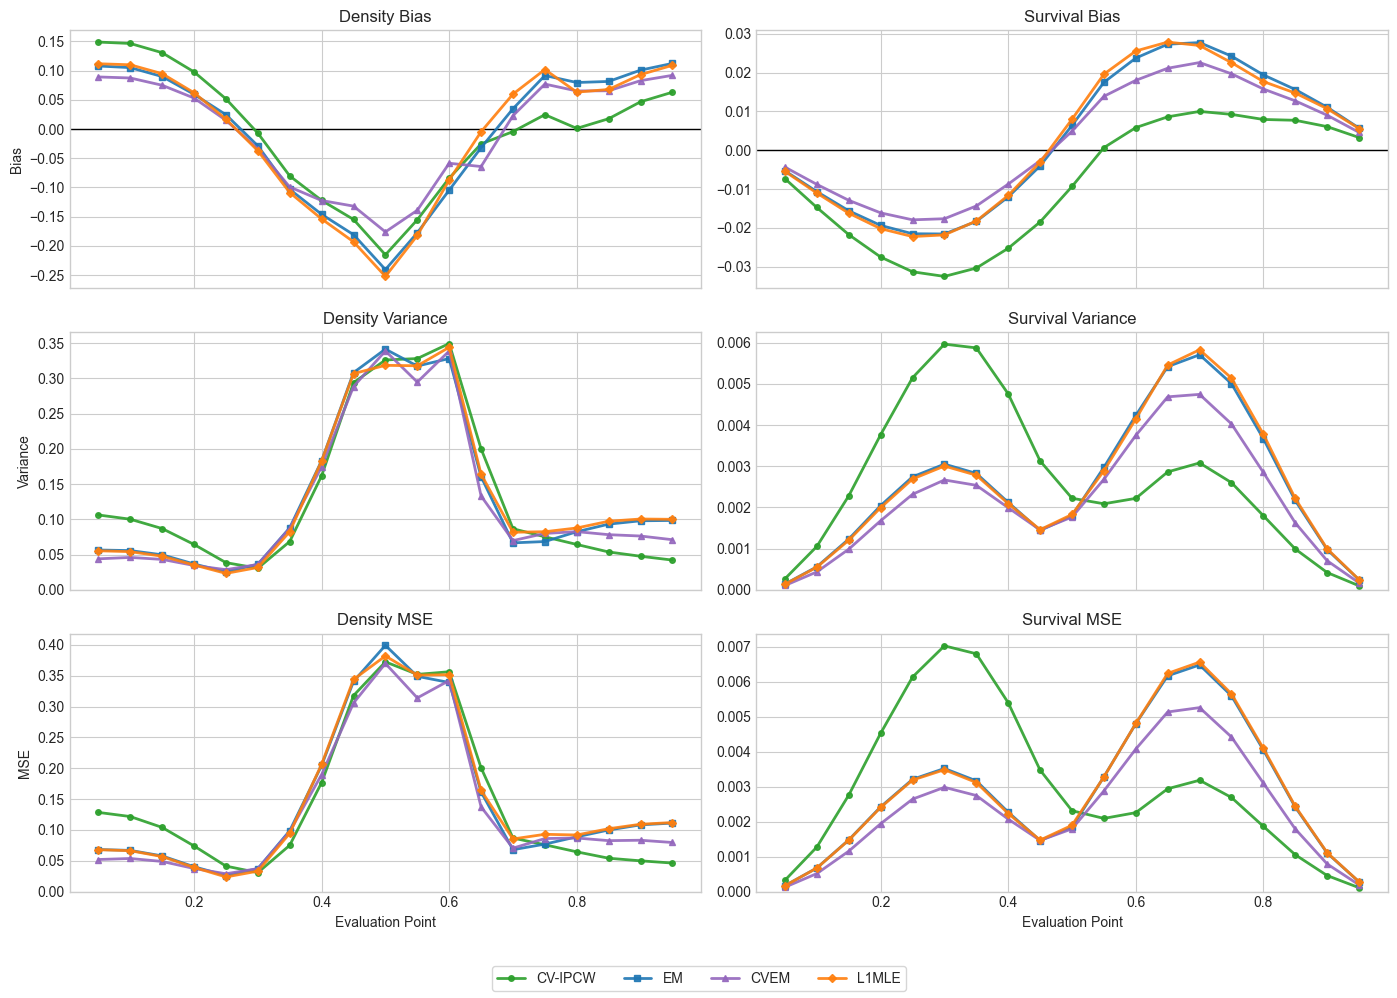

In [11]:
# Small-MC pointwise bias, variance, and MSE line plots.

pointwise_plot_methods = plot_method_order
pointwise_plot_colors = method_color_map
pointwise_plot_markers = {
    "CV-IPCW": "o",
    "EM": "s",
    "CVEM": "^",
    "L1MLE": "D",
}
metric_order = ["bias", "variance", "mse"]
estimand_order = ["density", "survival"]
metric_labels = {"bias": "Bias", "variance": "Variance", "mse": "MSE"}
estimand_labels = {"density": "Density", "survival": "Survival"}

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex="col")

for row_idx, metric in enumerate(metric_order):
    for col_idx, estimand in enumerate(estimand_order):
        ax = axes[row_idx, col_idx]
        if metric == "bias":
            ax.axhline(0.0, color="black", linewidth=1)

        for method in pointwise_plot_methods:
            method_df = pointwise_metric_summary[
                (pointwise_metric_summary["method"] == method)
                & (pointwise_metric_summary["estimand"] == estimand)
            ].sort_values("eval_point")
            ax.plot(
                method_df["eval_point"],
                method_df[metric],
                color=pointwise_plot_colors[method],
                linewidth=2,
                marker=pointwise_plot_markers[method],
                markersize=4,
                alpha=0.9,
                label=method,
            )

        ax.set_title(f"{estimand_labels[estimand]} {metric_labels[metric]}")
        if col_idx == 0:
            ax.set_ylabel(metric_labels[metric])
        if row_idx == len(metric_order) - 1:
            ax.set_xlabel("Evaluation Point")
        if metric in {"variance", "mse"}:
            ax.set_ylim(bottom=0.0)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(pointwise_plot_methods), frameon=True)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()


## Oracle-SD Coverage

This section reuses the existing 100-seed small-MC sweep and computes pointwise 95% coverage using the empirical Monte Carlo SD as an oracle standard error.

For survival, both linear and log-log interval coverage are shown so the centering behavior can be compared without mixing in standard-error estimation error. A true event-time KM baseline is also included for survival only.


,method,estimand,mean_oracle_sd,mean_abs_bias_over_sd,mean_linear_oracle_coverage,mean_loglog_oracle_coverage
0,CV-IPCW,density,0.338302,0.236788,0.908947,NaN
1,EM,density,0.335620,0.296304,0.905263,NaN
2,CVEM,density,0.323971,0.258882,0.903158,NaN
3,L1MLE,density,0.337198,0.298993,0.901579,NaN
4,CV-IPCW,survival,0.048047,0.298672,0.898421,0.893684
5,EM,survival,0.047186,0.346395,0.896316,0.893158
6,CVEM,survival,0.043455,0.307750,0.896842,0.895789
7,L1MLE,survival,0.047190,0.350329,0.894211,0.894211
8,Event KM,survival,0.026108,0.113580,0.942632,0.695789


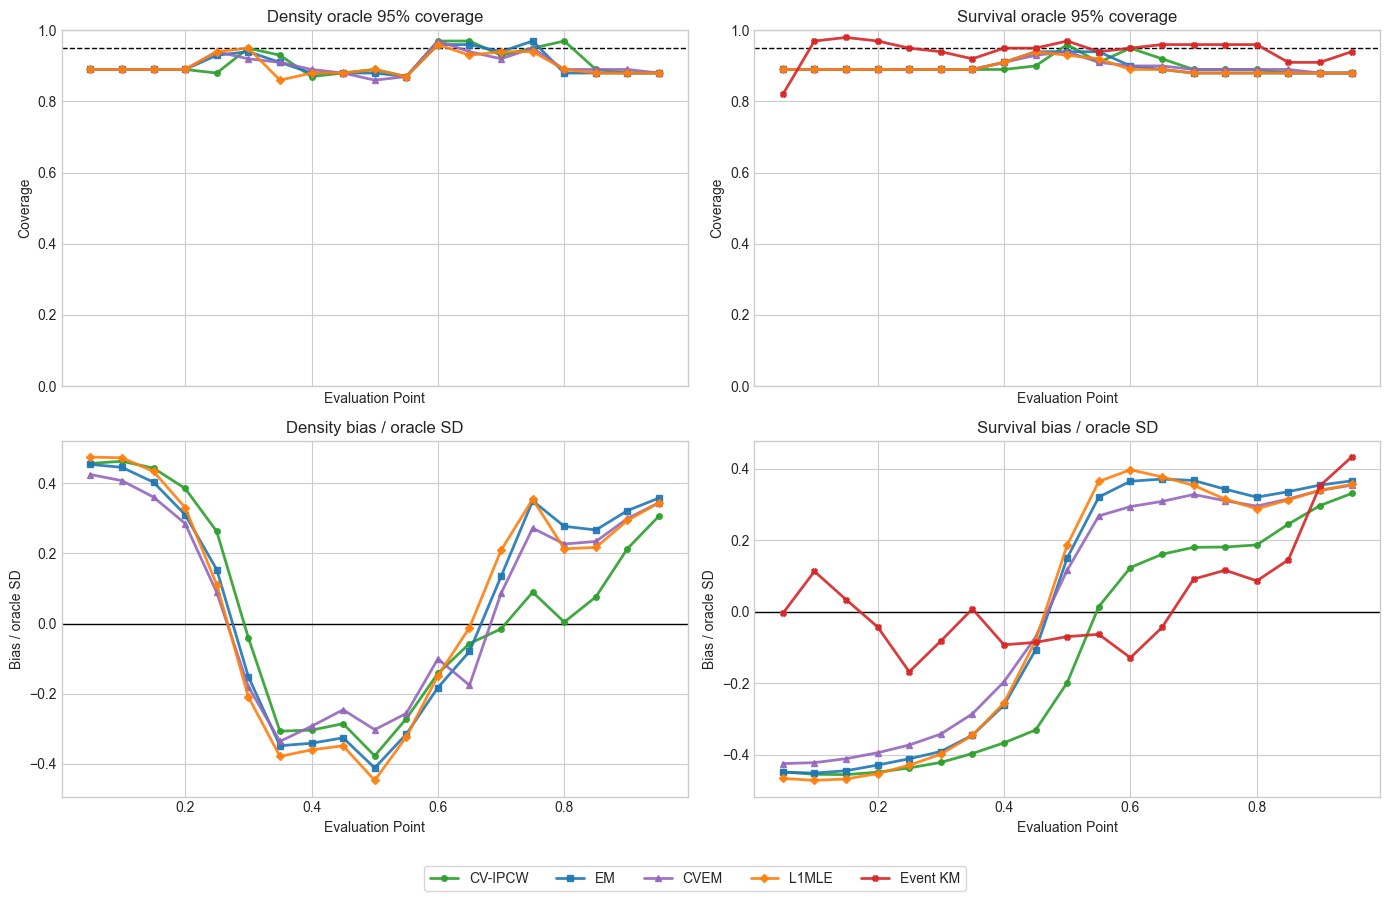

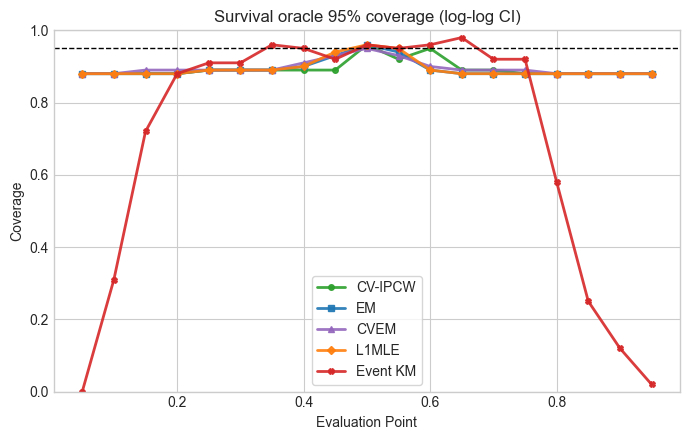

In [14]:
# Small-MC oracle-SD coverage and bias-over-SD summaries.

def nanmean_or_nan(values, *, absolute: bool = False) -> float:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if absolute:
        arr = np.abs(arr)
    return float(np.mean(arr)) if arr.size else float("nan")


def oracle_survival_loglog_ci(
    survival: np.ndarray,
    standard_error: np.ndarray,
    *,
    z: float = 1.96,
) -> tuple[np.ndarray, np.ndarray]:
    eps = 1e-10
    s = np.asarray(survival, dtype=float)
    se = np.asarray(standard_error, dtype=float)
    lower = np.full(s.shape, np.nan, dtype=float)
    upper = np.full(s.shape, np.nan, dtype=float)

    def inv_loglog(g_value: float) -> float:
        if g_value >= 700.0:
            return 0.0
        if g_value <= -745.0:
            return 1.0
        return float(np.exp(-np.exp(g_value)))

    for i, (si, sei) in enumerate(zip(s, se, strict=False)):
        if not np.isfinite(si):
            continue
        if si <= 0.0:
            lower[i] = 0.0
            upper[i] = 0.0
            continue
        if si >= 1.0:
            lower[i] = 1.0
            upper[i] = 1.0
            continue

        s_clip = float(np.clip(si, eps, 1.0 - eps))
        if not np.isfinite(sei) or sei < 0.0:
            lower[i] = 0.0
            upper[i] = 1.0
            continue

        log_s = float(np.log(s_clip))
        denom = float(s_clip * abs(log_s))
        if denom <= 0.0:
            lower[i] = 0.0
            upper[i] = 1.0
            continue

        se_g = float(sei / denom)
        g_hat = float(np.log(-log_s))
        g_lo = g_hat - z * se_g
        g_hi = g_hat + z * se_g
        lower[i] = float(np.clip(inv_loglog(g_hi), 0.0, 1.0))
        upper[i] = float(np.clip(inv_loglog(g_lo), 0.0, 1.0))

    return lower, upper


def event_time_km_survival(
    data: pd.DataFrame,
    grid: np.ndarray,
    *,
    time_col: str = "T",
    delta_col: str = "Delta",
) -> np.ndarray:
    y = np.asarray(data[time_col].values, dtype=float).ravel()
    delta = np.asarray(data[delta_col].values, dtype=int).ravel()

    order = np.argsort(y)
    y_sorted = y[order]
    delta_sorted = delta[order]

    unique_times, idx_start = np.unique(y_sorted, return_index=True)
    counts_at_time = np.diff(np.append(idx_start, len(y_sorted)))
    events_at_time = np.add.reduceat(delta_sorted, idx_start)
    at_risk = len(y_sorted) - np.cumsum(np.append(0, counts_at_time[:-1]))

    frac = np.clip(1.0 - (events_at_time / np.maximum(at_risk, 1)), 0.0, 1.0)
    surv = np.cumprod(frac, dtype=float)

    eval_grid = np.asarray(grid, dtype=float)
    idx = np.searchsorted(unique_times, eval_grid, side="right") - 1
    idx = np.clip(idx, -1, len(unique_times) - 1)
    return np.where(idx >= 0, surv[idx], 1.0)


oracle_summary_method_order = [*plot_method_order, "Event KM"]
oracle_method_color_map = dict(method_color_map)
oracle_method_color_map["Event KM"] = "tab:red"

oracle_pointwise_rows = list(pointwise_summary.to_dict(orient="records"))
eval_grid = np.asarray(POINTWISE_MSE_GRID, dtype=float)
for seed in SEED_SWEEP:
    simulation_seed = simulate_reference_right_censored_dgp(n=N, seed=seed)
    data_seed = simulation_seed["observed_data"]
    truth_seed = simulation_seed["truth"]
    km_survival = event_time_km_survival(data_seed, eval_grid)
    truth_survival = np.asarray(truth_seed["survival_fn"](eval_grid), dtype=float)
    for eval_point, estimate, truth_value in zip(
        eval_grid, km_survival, truth_survival, strict=False
    ):
        error = float(estimate - truth_value)
        oracle_pointwise_rows.append(
            {
                "seed": int(seed),
                "method": "Event KM",
                "estimand": "survival",
                "eval_point": float(eval_point),
                "estimate": float(estimate),
                "truth": float(truth_value),
                "error": error,
                "squared_error": float(error ** 2),
            }
        )

oracle_pointwise_summary = pd.DataFrame(oracle_pointwise_rows).sort_values(
    ["estimand", "method", "eval_point", "seed"]
).reset_index(drop=True)

oracle_interval_rows = []
for (method, estimand, eval_point), group in oracle_pointwise_summary.groupby(
    ["method", "estimand", "eval_point"],
    sort=True,
    observed=False,
):
    estimates = group["estimate"].to_numpy(dtype=float)
    truth_value = float(group["truth"].iloc[0])
    mean_estimate = float(np.mean(estimates))
    bias = float(mean_estimate - truth_value)
    oracle_sd = float(np.std(estimates, ddof=0))
    bias_over_sd = (
        float(bias / oracle_sd)
        if np.isfinite(oracle_sd) and oracle_sd > 1e-12
        else float("nan")
    )
    linear_coverage = float(np.mean(np.abs(estimates - truth_value) <= (1.96 * oracle_sd)))

    loglog_coverage = float("nan")
    if str(estimand) == "survival":
        loglog_lo, loglog_hi = oracle_survival_loglog_ci(
            survival=estimates,
            standard_error=np.full(estimates.shape, oracle_sd, dtype=float),
        )
        loglog_coverage = float(np.mean((truth_value >= loglog_lo) & (truth_value <= loglog_hi)))

    oracle_interval_rows.append(
        {
            "method": method,
            "estimand": estimand,
            "eval_point": float(eval_point),
            "n_seeds": int(group["seed"].nunique()),
            "truth": truth_value,
            "mean_estimate": mean_estimate,
            "bias": bias,
            "oracle_sd": oracle_sd,
            "bias_over_sd": bias_over_sd,
            "oracle_ci_coverage": linear_coverage,
            "oracle_ci_coverage_loglog": loglog_coverage,
        }
    )

oracle_interval_summary = pd.DataFrame(oracle_interval_rows)
oracle_interval_summary["method"] = pd.Categorical(
    oracle_interval_summary["method"], categories=oracle_summary_method_order, ordered=True
)
oracle_interval_summary = oracle_interval_summary.sort_values(
    ["estimand", "method", "eval_point"]
).reset_index(drop=True)

oracle_metric_overview = (
    oracle_interval_summary.groupby(["method", "estimand"], observed=True)
    .agg(
        mean_oracle_sd=("oracle_sd", "mean"),
        mean_abs_bias_over_sd=("bias_over_sd", lambda s: nanmean_or_nan(s, absolute=True)),
        mean_linear_oracle_coverage=("oracle_ci_coverage", nanmean_or_nan),
        mean_loglog_oracle_coverage=("oracle_ci_coverage_loglog", nanmean_or_nan),
    )
    .reset_index()
)
oracle_metric_overview["method"] = pd.Categorical(
    oracle_metric_overview["method"], categories=oracle_summary_method_order, ordered=True
)
oracle_metric_overview = oracle_metric_overview.sort_values(
    ["estimand", "method"]
).reset_index(drop=True)

display(oracle_metric_overview)

oracle_plot_markers = (
    dict(pointwise_plot_markers)
    if "pointwise_plot_markers" in globals()
    else {method: "o" for method in oracle_summary_method_order}
)
oracle_plot_markers["Event KM"] = "X"

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex="col")
plot_specs = [
    ("density", "oracle_ci_coverage", "Density oracle 95% coverage", 0.95),
    ("survival", "oracle_ci_coverage", "Survival oracle 95% coverage", 0.95),
    ("density", "bias_over_sd", "Density bias / oracle SD", 0.0),
    ("survival", "bias_over_sd", "Survival bias / oracle SD", 0.0),
]

for ax, (estimand, metric, title, reference) in zip(axes.flat, plot_specs, strict=True):
    if metric == "oracle_ci_coverage":
        ax.axhline(reference, color="black", linewidth=1, linestyle="--")
        ax.set_ylim(0.0, 1.0)
    else:
        ax.axhline(reference, color="black", linewidth=1)

    panel_methods = oracle_summary_method_order if estimand == "survival" else plot_method_order
    for method in panel_methods:
        method_df = oracle_interval_summary[
            (oracle_interval_summary["method"] == method)
            & (oracle_interval_summary["estimand"] == estimand)
        ].sort_values("eval_point")
        if method_df.empty:
            continue
        ax.plot(
            method_df["eval_point"],
            method_df[metric],
            color=oracle_method_color_map[method],
            linewidth=2,
            marker=oracle_plot_markers[method],
            markersize=4,
            alpha=0.9,
            label=method,
        )

    ax.set_title(title)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("Coverage" if metric == "oracle_ci_coverage" else "Bias / oracle SD")

handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=True)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
for method in oracle_summary_method_order:
    method_df = oracle_interval_summary[
        (oracle_interval_summary["method"] == method)
        & (oracle_interval_summary["estimand"] == "survival")
    ].sort_values("eval_point")
    if method_df.empty:
        continue
    ax.plot(
        method_df["eval_point"],
        method_df["oracle_ci_coverage_loglog"],
        color=oracle_method_color_map[method],
        linewidth=2,
        marker=oracle_plot_markers[method],
        markersize=4,
        alpha=0.9,
        label=method,
    )

ax.axhline(0.95, color="black", linewidth=1, linestyle="--")
ax.set_ylim(0.0, 1.0)
ax.set_title("Survival oracle 95% coverage (log-log CI)")
ax.set_xlabel("Evaluation Point")
ax.set_ylabel("Coverage")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## Takeaways

This notebook now keeps only the clean four-method comparison:

- `CV-IPCW`
- `EM`
- `CVEM`
- `L1MLE`

The event-time data-generating process is now a truncated normal on `[0, 1]` with independent uniform censoring. The small-MC section therefore summarizes how these four methods behave under a smoother single-mode truth rather than the earlier mixture design.
